## Adversarial Attack Evaluation Notebook

Run encoder and diffusion attacks on custom images or random samples from YFCC4k/OSV-5M datasets.

### Usage

This notebook loads images either from:
- A custom file path (e.g., your own image)
- A random sample from YFCC4k dataset
- A random sample from OSV-5M dataset

Then runs encoder or diffusion attacks and visualizes the results.

Set the configuration below and run each cell in order.

In [ ]:
#Go to adversarial_demo. Only execute once. If you execute more times, restart kernel.
%cd ../

/users/eleves-b/2023/mathias.ollu/repos/plonk/adversarial_demo


In [6]:
import sys
from pathlib import Path
import yaml
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np

from attacks import run_attack
from pipe_trajectory import PlonkPipelineTrajectory
from adversarial_utils import (
    add_perturbation_to_image,
    conditional_preprocessing,
    tensor_to_pil,
    run_paired_pipeline_with_shared_noise,
    resolve_torch_device,
)
from plots_adversarial_attacks import plot_gps_samples_on_map, plot_gps_trajectories_on_map

print("Imports successful")

Imports successful


In [7]:
# Load configuration from config.yaml
config_path = Path("config.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

print(f"Config loaded from {config_path}")
print(f"Data root: {config.get('data_root')}")
print(f"Device: {config.get('device')}")
print(f"Available pipelines: {list(config.get('pipelines', {}).keys())}")

Config loaded from config.yaml
Data root: /Data/mathias.ollu/hf_cache/datasets
Device: cuda
Available pipelines: ['yfcc', 'osv']


In [45]:
# === Configuration ===
# Choose dataset: "yfcc", "osv", or "custom"
IMAGE_SOURCE = "custom"  # Options: "yfcc", "osv", "custom"
CUSTOM_IMAGE_PATH = "../.media/attacked_images_geoshield/img/7c8ee26cf3a0abd0802ceacfe8115cac+geoshield/clean_images/random_osv.png  # Set to image path if IMAGE_SOURCE == "custom"
# Choose attack
ATTACK_TYPE = "diffusion"  # Options: "encoder", "diffusion"
ATTACK_BUDGET = 8 / 255
N_STEPS = 10
N_RESTARTS=1 
    
# Device
device = resolve_torch_device(config.get("device", "cuda"))
print(f"Using device: {device}")

SyntaxError: unterminated string literal (detected at line 4) (3222215795.py, line 4)

In [46]:
# Initialize pipeline
dataset = "yfcc" if IMAGE_SOURCE in ["yfcc", "custom"] else "osv"
pipeline_name = config["pipelines"].get(dataset)
if not pipeline_name:
    raise ValueError(f"No pipeline configured for dataset: {dataset}")

print(f"Loading pipeline: {pipeline_name}")
pipeline = PlonkPipelineTrajectory(pipeline_name).to(device)
print("Pipeline loaded")

Loading pipeline: nicolas-dufour/PLONK_YFCC_diffusion


Using cache found in /users/eleves-b/2023/mathias.ollu/.cache/torch/hub/facebookresearch_dinov2_main


Pipeline loaded


Loaded custom image from ../.media/attacked_images_geoshield/img/e44606c9ce5dffed9753544e7ca36643+geoshield/clean_images/random_osv.png
Image shape: (640, 640)


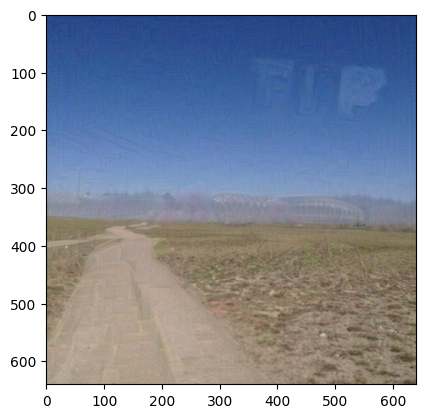

In [47]:
# Load source image
if IMAGE_SOURCE == "custom":
    if not CUSTOM_IMAGE_PATH:
        raise ValueError("Set CUSTOM_IMAGE_PATH above")
    source_image = Image.open(CUSTOM_IMAGE_PATH).convert("RGB")
    print(f"Loaded custom image from {CUSTOM_IMAGE_PATH}")
    
elif IMAGE_SOURCE == "yfcc":
    import random
    import os
    from adversarial_eval import retrieve_yfcc_images
    
    yfcc_dir = config["data_dirs"]["yfcc"]
    images, _ = retrieve_yfcc_images(n_images_to_eval=100, local_dir=yfcc_dir)
    #random image:
    i_img = random.randint(0, len(images)-1)
    source_image = images[i_img]
    print(f"Loaded random YFCC4k image from {yfcc_dir}")
    
elif IMAGE_SOURCE == "osv":
    from adversarial_eval import retrieve_osv_images
    
    osv_dir = config["data_dirs"]["osv"]
    images, _ = retrieve_osv_images(n_images_to_eval=100, local_dir=osv_dir)
    source_image = images[0]
    print(f"Loaded random OSV-5M image from {osv_dir}")
else:
    raise ValueError(f"Unknown IMAGE_SOURCE: {IMAGE_SOURCE}")

print(f"Image shape: {source_image.size}")
#show image:
plt.imshow(source_image)

In [48]:
# Run attack
print(f"\nRunning {ATTACK_TYPE} attack with budget {ATTACK_BUDGET*255}/255...")

attack_kwargs = {
    "n_steps": N_STEPS,
    "eps_max": ATTACK_BUDGET,
    "lr": 1e-3,
    "device": device,
}

# Add attack-specific parameters
if ATTACK_TYPE == "diffusion":
    attack_kwargs.update({
        "train_batch_size": 256,
        "anchor_samples": 512,
        "clean_num_steps": 100,
        "dot_product_loss": "absolute",
        "reconstruction_loss_weight": 0.0,
        "num_restarts": N_RESTARTS,
        "restart_selection_metric": "final_step_displacement",
        "restart_eval_cfg": 10.0,
    })
elif ATTACK_TYPE == "encoder":
    attack_kwargs.update({
        "criterion_name": "MSE",
        "l_z": 1.0,
        "l_x": 1.0,
        "num_restarts": 3,
        "restart_selection_metric": "final_step_displacement",
    })

results = run_attack(
    attack_type=ATTACK_TYPE,
    source_image=source_image,
    pipeline=pipeline,
    silent=False,
    **attack_kwargs
)

delta = results["delta"]
print(f"Attack complete. Delta shape: {delta.shape}")


Running diffusion attack with budget 8.0/255...
Building x0 bank (shared across restarts)...


/users/eleves-b/2023/mathias.ollu/repos/plonk/plonk/models/samplers/ddim.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):
Attack training (restart 1/1): 100%|██████████| 10/10 [00:03<00:00,  3.30it/s]


[restart 1/1] final_loss=1.808175, min_loss=1.808175, mean_step_disp=nan, final_step_disp=6787.893066, selection_score=6787.893066
Attack complete. Delta shape: torch.Size([1, 3, 336, 336])


In [49]:
# Evaluate trajectories with shared noise
print("\nEvaluating trajectories...")

perturbed_image = add_perturbation_to_image(source_image, delta, pipeline)

#optionally, train a GeoShield attack to image for comparison: 

# perturbed_image_geoshield = add_perturbation_to_image(source_image, delta, pipeline, geoshield=True)

eval_result = run_paired_pipeline_with_shared_noise(
    pipeline=pipeline,
    source_image=source_image,
    perturbed_image=perturbed_image,
    batch_size=1024,
    cfg=10.0,
    num_steps=None,
    seed=1234,
    device=device,
)

gps_source = eval_result["gps_source"]
gps_perturbed = eval_result["gps_perturbed"]
traj_source = eval_result["traj_source"]
traj_perturbed = eval_result["traj_perturbed"]
metrics = eval_result["metrics"]

print(f"Metrics: {metrics}")
print(f"Mean step displacement: {metrics['mean_step_displacement']:.2f} km")
print(f"Final step displacement: {metrics['final_step_displacement']:.2f} km")


Evaluating trajectories...
Metrics: {'mean_step_displacement': nan, 'final_step_displacement': 6761.16015625}
Mean step displacement: nan km
Final step displacement: 6761.16 km


Plotting results...



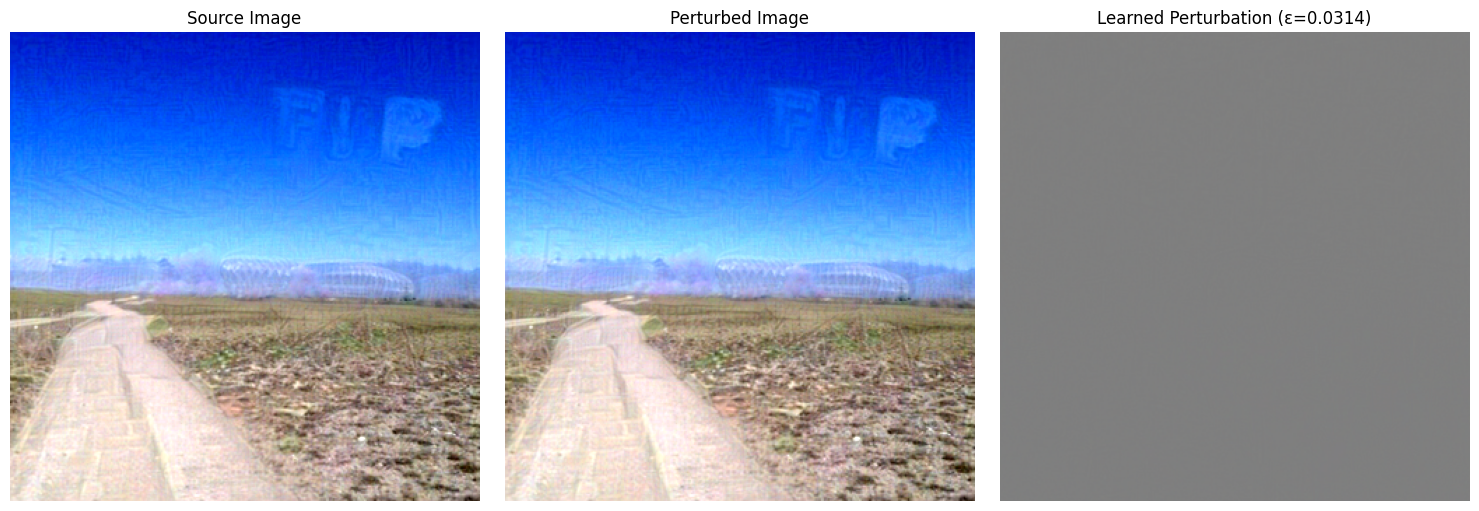


GPS Coordinates:
  Source final: [54.00134   -1.6044315]
  Perturbed final: [32.202354 59.749268]
  Displacement: 6761.16 km


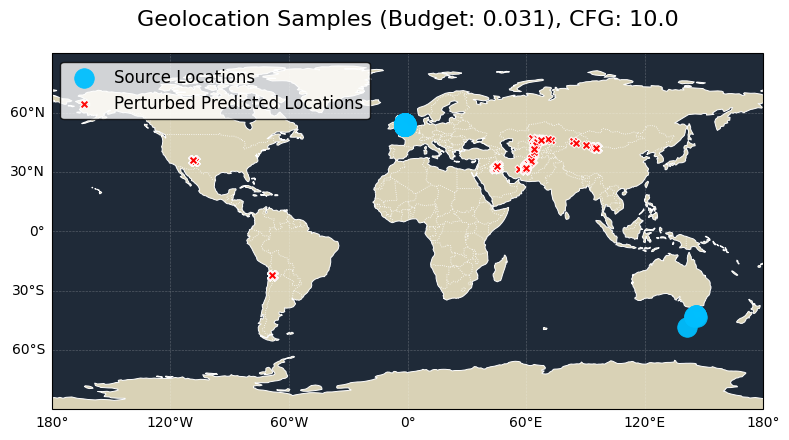

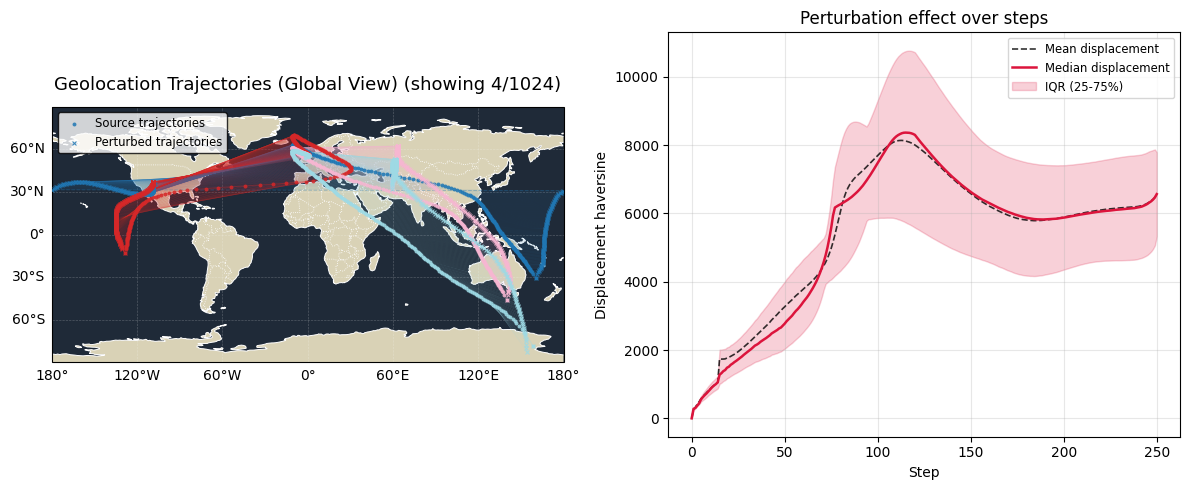

In [50]:
# Visualize results
print("Plotting results...\n")

# Plot source, perturbed, and delta
source_tensor = conditional_preprocessing(source_image, pipeline, device=device)
source_image_processed = tensor_to_pil(source_tensor.squeeze(0))
delta_pil = tensor_to_pil(delta)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(source_image_processed)
axs[0].set_title("Source Image")
axs[0].axis("off")

axs[1].imshow(perturbed_image)
axs[1].set_title("Perturbed Image")
axs[1].axis("off")

axs[2].imshow(delta_pil)
axs[2].set_title(f"Learned Perturbation (ε={ATTACK_BUDGET:.4f})")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# Plot GPS trajectories
print("\nGPS Coordinates:")
print(f"  Source final: {gps_source[-1]}")
print(f"  Perturbed final: {gps_perturbed[-1]}")
print(f"  Displacement: {metrics['final_step_displacement']:.2f} km")

try:
    plot_gps_samples_on_map(
        gps_source, None, gps_perturbed,
        perturb_budget=ATTACK_BUDGET,
        cfg=10.0,
        point_size=40
    )
    plot_gps_trajectories_on_map(
        traj_source, traj_perturbed,
        show_map=True, show_paths=True,
        show_displacement=True, max_trajectories=4
    )
except Exception as e:
    print(f"Note: Could not plot maps (basemap may not be installed): {e}")